In [1]:
import os
import re 
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw
pd.set_option("display.max_colwidth", 120)

import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"    

In [2]:
wind  = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

## tables just like B.1 

In [3]:
def add_diff_columns(df):
    df = df.copy()

    df["diff% pGWP_fixedCO2"] = (
        (df["pGWP100_fixedCO2"] - df["gwp100"]) / df["gwp100"] * 100
    ).round(0).astype(int)

    df["diff% pGWP_dpCO2"] = (
        (df["pGWP100_dpCO2"] - df["gwp100"]) / df["gwp100"] * 100
    ).round(0).astype(int)

    return df


In [4]:
hydro = add_diff_columns(hydro)
wind  = add_diff_columns(wind)
pv    = add_diff_columns(pv)

In [5]:
def highlight_threshold(val):
    if pd.isna(val):
        return ""
    if abs(val) >= 10:
        return "background-color: #ff6b6b; color: black;"   # red
    elif abs(val) >= 5:
        return "background-color: #f4b084; color: black;"   # yellow
    else:
        return ""



In [6]:

hydro.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_5374/4053345779.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  hydro.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",0.027212,0.028281,0.027695,4,2
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2040",0.015028,0.014986,0.015086,0,0
2,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",0.025149,0.025655,0.026053,2,4
3,"market for electricity, hydro, high voltage, US, SSP2-M, 2030",0.027237,0.031584,0.027120,16,0
4,"market for electricity, hydro, high voltage, US, SSP2-M, 2040",0.015562,0.017235,0.015566,11,0
5,"market for electricity, hydro, high voltage, US, SSP2-M, 2050",0.026952,0.028855,0.027409,7,2
6,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",0.027293,0.035153,0.025494,29,-7
7,"market for electricity, hydro, high voltage, US, SSP5-H, 2040",0.015678,0.020514,0.015533,31,-1
8,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",0.027074,0.032042,0.025919,18,-4
9,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",0.050523,0.051877,0.050841,3,1


In [7]:
# wind and PV has 2040 rows, and we don't use them 
wind = wind[wind["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]

wind.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_5374/915099166.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  wind = wind[wind["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_5374/915099166.py:4: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  wind.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2030",0.036906,0.037424,0.036701,1,-1
2,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050",0.017833,0.017480,0.017768,-2,0
3,"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2030",0.037725,0.043338,0.037299,15,-1
5,"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2050",0.031186,0.032591,0.030982,5,-1
6,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2030",0.038735,0.051867,0.037741,34,-3
8,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050",0.034396,0.041592,0.033688,21,-2
9,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2030",0.020638,0.020928,0.020523,1,-1
11,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2050",0.009972,0.009775,0.009936,-2,0
12,"market for electricity, wind, high voltage, US-TRE, SSP2-M, 2030",0.021096,0.024235,0.020858,15,-1
14,"market for electricity, wind, high voltage, US-TRE, SSP2-M, 2050",0.017439,0.018225,0.017325,5,-1


In [8]:
pv = pv[pv["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]
pv.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )

/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_5374/637759440.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pv = pv[pv["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_5374/637759440.py:2: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pv.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2030",0.032006,0.031884,0.031264,0,-2
2,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2050",0.010068,0.009403,0.009556,-7,-5
3,"market for electricity, PV, low voltage, CN, SSP2-M, 2030",0.032915,0.037194,0.031987,13,-3
5,"market for electricity, PV, low voltage, CN, SSP2-M, 2050",0.020244,0.020667,0.019644,2,-3
6,"market for electricity, PV, low voltage, CN, SSP5-H, 2030",0.034537,0.045568,0.033106,32,-4
8,"market for electricity, PV, low voltage, CN, SSP5-H, 2050",0.024785,0.029432,0.023822,19,-4
9,"market for electricity, PV, low voltage, US, SSP1-VLLO, 2030",0.020106,0.020041,0.019651,0,-2
11,"market for electricity, PV, low voltage, US, SSP1-VLLO, 2050",0.006562,0.006146,0.006247,-6,-5
12,"market for electricity, PV, low voltage, US, SSP2-M, 2030",0.020740,0.023453,0.020169,13,-3
14,"market for electricity, PV, low voltage, US, SSP2-M, 2050",0.013046,0.013334,0.012675,2,-3


## plots 

In [9]:
all_df = pd.concat([hydro, wind, pv], ignore_index=True)
all_df.columns = [str(c).strip() for c in all_df.columns]

diff_fixed_col = next(c for c in all_df.columns if "diff% pGWP_fixedCO2" in c)
diff_dp_col    = next(c for c in all_df.columns if "diff% pGWP_dpCO2" in c)

In [10]:
all_df

,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",0.027212,0.028281,0.027695,4,2
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2040",0.015028,0.014986,0.015086,0,0
2,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",0.025149,0.025655,0.026053,2,4
3,"market for electricity, hydro, high voltage, US, SSP2-M, 2030",0.027237,0.031584,0.027120,16,0
4,"market for electricity, hydro, high voltage, US, SSP2-M, 2040",0.015562,0.017235,0.015566,11,0
5,"market for electricity, hydro, high voltage, US, SSP2-M, 2050",0.026952,0.028855,0.027409,7,2
6,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",0.027293,0.035153,0.025494,29,-7
7,"market for electricity, hydro, high voltage, US, SSP5-H, 2040",0.015678,0.020514,0.015533,31,-1
8,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",0.027074,0.032042,0.025919,18,-4
9,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",0.050523,0.051877,0.050841,3,1


In [11]:
def infer_region(s):
    s = str(s)
    if ", US," in s or ", US " in s or re.search(r"\bUS\b", s):
        return "US"
    if ", CN," in s or ", CN " in s or re.search(r"\bCN\b", s):
        return "CN"
    return None

def infer_scenario(s):
    s = str(s)
    if "SSP1-VLLO" in s: return "SSP1-VLLO"
    if "SSP5-H" in s:    return "SSP5-H"
    if "SSP2-M" in s:    return "SSP2-M"
    return None

def infer_year(s):
    m = re.search(r",\s*(20\d{2})\s*$", str(s))
    return int(m.group(1)) if m else None

def infer_tech(s):
    s = str(s).lower()
    if "hydro" in s: return "hydro"
    if "wind" in s:  return "wind"
    if "solar" in s or " pv" in s or "pv," in s: return "pv"
    return None

tidy = pd.DataFrame({
    "Activity": all_df["Activity"],
    "region": all_df["Activity"].map(infer_region),
    "scenario": all_df["Activity"].map(infer_scenario),
    "year": all_df["Activity"].map(infer_year),
    "tech": all_df["Activity"].map(infer_tech),
    "diff_fixed": pd.to_numeric(all_df[diff_fixed_col], errors="coerce"),
    "diff_dp": pd.to_numeric(all_df[diff_dp_col], errors="coerce"),
})

df2050 = tidy[
    (tidy["year"] == 2050) &
    (tidy["scenario"].isin(["SSP1-VLLO", "SSP5-H"])) &
    (tidy["tech"].isin(["hydro", "wind", "pv"])) &
    (tidy["region"].isin(["US", "CN"]))
].drop_duplicates(subset=["tech","region","scenario"]).copy()


df2050

,Activity,region,scenario,year,tech,diff_fixed,diff_dp
2,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,hydro,2,4
8,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",US,SSP5-H,2050,hydro,18,-4
11,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,hydro,0,1
17,"market for electricity, hydro, high voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,hydro,22,-2
19,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,wind,-2,0
23,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050",CN,SSP5-H,2050,wind,21,-2
25,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,wind,-2,0
29,"market for electricity, wind, high voltage, US-TRE, SSP5-H, 2050",US,SSP5-H,2050,wind,21,-2
31,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,pv,-7,-5
35,"market for electricity, PV, low voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,pv,19,-4


### only 2050 plot 

### adding 2030 

In [12]:
df203050 = (
    tidy[
        (tidy["year"].isin([2030, 2050])) &
        (tidy["scenario"].isin(["SSP1-VLLO", "SSP2-M", "SSP5-H"])) &
        (tidy["tech"].isin(["hydro", "wind", "pv"])) &
        (tidy["region"].isin(["US", "CN"]))
    ]
    .drop_duplicates(subset=["year", "tech", "region", "scenario"])
    .copy()
)

df203050.sort_values(["tech","region","year","scenario"], inplace=True)
df203050

,Activity,region,scenario,year,tech,diff_fixed,diff_dp
9,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",CN,SSP1-VLLO,2030,hydro,3,1
12,"market for electricity, hydro, high voltage, CN, SSP2-M, 2030",CN,SSP2-M,2030,hydro,16,0
15,"market for electricity, hydro, high voltage, CN, SSP5-H, 2030",CN,SSP5-H,2030,hydro,34,-3
11,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,hydro,0,1
14,"market for electricity, hydro, high voltage, CN, SSP2-M, 2050",CN,SSP2-M,2050,hydro,6,1
17,"market for electricity, hydro, high voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,hydro,22,-2
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",US,SSP1-VLLO,2030,hydro,4,2
3,"market for electricity, hydro, high voltage, US, SSP2-M, 2030",US,SSP2-M,2030,hydro,16,0
6,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",US,SSP5-H,2030,hydro,29,-7
2,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,hydro,2,4


#### plot 2 SSP 

### more scnearios , not hard-coded just two scn

In [14]:
def plot_fixedCO2_dumbbell_2030_2050_oneflag(
    df,
    figsize=(9, 5),
    tech_order=("hydro", "wind", "pv"),
    region_order=("US", "CN"),
    year_order=(2030, 2050),
    scenario_order=None,
    scenario_color_map=None,
):

    # ----------------------------
    # 0. Column harmonization
    # ----------------------------
    df = df.copy()

    rename_map = {}
    if "Technology" in df.columns:
        rename_map["Technology"] = "tech"
    if "Country" in df.columns:
        rename_map["Country"] = "region"
    if "SSP" in df.columns:
        rename_map["SSP"] = "scenario"
    if "Year" in df.columns:
        rename_map["Year"] = "year"
    if "Score" in df.columns:
        rename_map["Score"] = "diff_fixed"

    if rename_map:
        df = df.rename(columns=rename_map)

    required_cols = {"tech", "region", "scenario", "year", "diff_fixed"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # ----------------------------
    # 1. Normalize values
    # ----------------------------
    df["tech"] = df["tech"].astype(str).str.strip().str.lower()
    df["region"] = df["region"].astype(str).str.strip().str.upper()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    df["year"] = df["year"].astype(int)
    df["diff_fixed"] = pd.to_numeric(df["diff_fixed"], errors="coerce")

    # normalize tech_order too
    tech_order = [str(t).strip().lower() for t in tech_order]
    region_order = [str(r).strip().upper() for r in region_order]

    if scenario_order is None:
        default_pref = ["SSP1-VLLO", "SSP2-M", "SSP5-H"]
        present = list(df["scenario"].dropna().unique())
        scenario_order = [s for s in default_pref if s in present] + [s for s in present if s not in default_pref]

    if scenario_color_map is None:
        scenario_color_map = {
            "SSP1-VLLO": "#2c7bb6",
            "SSP2-M": "#fdae61",
            "SSP5-H": "#d7191c",
        }


   
    scenario_label_map = {
    "SSP1-VLLO": "SSP1-19",
    "SSP2-M": "SSP2-45",
    "SSP5-H": "SSP5-85",
    }
        

    fallback_cycle = [
        "#1f77b4", "#ff7f0e", "#7f7f7f", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#bcbd22", "#17becf"
    ]
    for i, scn in enumerate(scenario_order):
        if scn not in scenario_color_map:
            scenario_color_map[scn] = fallback_cycle[i % len(fallback_cycle)]

    # ----------------------------
    # 2. Flag helpers
    # ----------------------------
    def make_flag_US(w=120, h=80):
        img = Image.new("RGBA", (w, h), (255, 255, 255, 0))
        d = ImageDraw.Draw(img)
        stripe_h = h / 13
        red = (178, 34, 52, 255)
        white = (255, 255, 255, 255)
        for i in range(13):
            y0 = int(i * stripe_h)
            y1 = int((i + 1) * stripe_h)
            d.rectangle([0, y0, w, y1], fill=red if i % 2 == 0 else white)
        blue = (60, 59, 110, 255)
        cw = int(w * 0.4)
        ch = int(h * 0.54)
        d.rectangle([0, 0, cw, ch], fill=blue)
        for r in range(5):
            for c in range(6):
                x = int((c + 1) * cw / 7)
                y = int((r + 1) * ch / 6)
                d.ellipse([x - 2, y - 2, x + 2, y + 2], fill=(255, 255, 255, 255))
        return np.asarray(img)

    def make_flag_CN(w=120, h=80):
        img = Image.new("RGBA", (w, h), (255, 255, 255, 0))
        d = ImageDraw.Draw(img)
        red = (222, 41, 16, 255)
        yellow = (255, 222, 0, 255)
        d.rectangle([0, 0, w, h], fill=red)
        cx, cy = int(w * 0.18), int(h * 0.25)
        r1, r2 = 14, 6
        pts = []
        for k in range(10):
            ang = (np.pi / 2) + k * np.pi / 5
            r = r1 if k % 2 == 0 else r2
            pts.append((cx + int(r * np.cos(ang)), cy - int(r * np.sin(ang))))
        d.polygon(pts, fill=yellow)
        for (sx, sy) in [
            (int(w * 0.32), int(h * 0.12)),
            (int(w * 0.38), int(h * 0.22)),
            (int(w * 0.38), int(h * 0.36)),
            (int(w * 0.32), int(h * 0.46)),
        ]:
            d.ellipse([sx - 4, sy - 4, sx + 4, sy + 4], fill=yellow)
        return np.asarray(img)

    flag_img = {"US": make_flag_US(), "CN": make_flag_CN()}

    def add_flag(ax, x, y, img_arr, zoom=0.16, alpha=0.95, zorder=1):
        im = OffsetImage(img_arr, zoom=zoom)
        ab = AnnotationBbox(im, (x, y), frameon=False, box_alignment=(0.5, 0.5), zorder=zorder)
        ab.set_alpha(alpha)
        ax.add_artist(ab)

    # ----------------------------
    # 3. Layout
    # ----------------------------
    x_base = {t: i for i, t in enumerate(tech_order)}
    dx_region = {"US": -0.10, "CN": +0.10}
    dx_year = {2030: -0.035, 2050: +0.035}
    marker_by_year = {2030: "^", 2050: "o"}

    ymax = float(np.nanmax(np.abs(df["diff_fixed"].values)))
    ymax = max(5, float(np.ceil(ymax / 5) * 5))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    for i in range(len(tech_order) - 1):
        ax.axvline(i + 0.5, linewidth=1.6, color="0.70", alpha=0.9)

    # ----------------------------
    # 4. Plot
    # ----------------------------
    for tech in tech_order:
        for region in region_order:
            all_vals_for_flag = []

            for year in year_order:
                x0 = x_base[tech] + dx_region[region] + dx_year[year]

                sub = df[
                    (df["tech"] == tech) &
                    (df["region"] == region) &
                    (df["year"] == year) &
                    (df["scenario"].isin(scenario_order))
                ].copy()

                if sub.empty:
                    continue

                # keep scenario plotting order
                sub["scenario"] = pd.Categorical(sub["scenario"], categories=scenario_order, ordered=True)
                sub = sub.sort_values("scenario")

                yvals = sub["diff_fixed"].tolist()
                all_vals_for_flag.extend(yvals)

                # straight vertical connector
                if len(yvals) >= 2:
                    ax.plot(
                        [x0, x0],
                        [min(yvals), max(yvals)],
                        linewidth=1.4,
                        alpha=0.85,
                        zorder=2,
                        color="0.55",
                    )

                for _, row in sub.iterrows():
                    ax.scatter(
                        x0,
                        row["diff_fixed"],
                        s=64,
                        marker=marker_by_year[year],
                        edgecolor=scenario_color_map[row["scenario"]],
                        facecolor=scenario_color_map[row["scenario"]],
                        linewidth=1.1,
                        zorder=3,
                    )

            if all_vals_for_flag:
                x_flag = x_base[tech] + dx_region[region]
                y_flag = float(np.mean(all_vals_for_flag))
                y_flag += (0.8 if region == "CN" else -0.8)
                add_flag(ax, x_flag, y_flag, flag_img[region], zoom=0.16, alpha=0.95, zorder=1)

    # ----------------------------
    # 5. Axes
    # ----------------------------
    tech_label_map = {"hydro": "Hydro", "wind": "Wind", "pv": "Solar PV"}
    ax.set_xticks([x_base[t] for t in tech_order])
    ax.set_xticklabels([tech_label_map.get(t, t) for t in tech_order])

    ax.set_ylabel("pGWP100[fixedCO$_2$],\nchange (%) to IPCC GWP100 reference (the central 0% line)")
    ax.set_ylim(-ymax, ymax)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v:g}%"))

    
    # ----------------------------
    # 6. Legends
    # ----------------------------
    scenario_handles = [
        mlines.Line2D(
            [], [], color=scenario_color_map[scn], marker="o", linestyle="None",
            markersize=6.5, markerfacecolor=scenario_color_map[scn],
            markeredgewidth=1.0, label=scenario_label_map.get(scn, scn)
        )
        for scn in scenario_order
    ]
    
    year_handles = [
        mlines.Line2D(
            [], [], color="black", marker=marker_by_year[yr], linestyle="None",
            markersize=6.5, markerfacecolor="black", markeredgewidth=1.0, label=str(yr)
        )
        for yr in year_order
    ]
    
    leg1 = ax.legend(
        handles=scenario_handles,
        title="Scenario",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.23),   # moved much higher
        ncol=len(scenario_handles),
        frameon=True,
        fancybox=True,
        framealpha=1.0,
    )
    leg1.get_frame().set_facecolor((1, 1, 1, 0.15))
    leg1.get_frame().set_edgecolor("0.6")
    ax.add_artist(leg1)
    
    leg2 = ax.legend(
        handles=year_handles,
        title="Model year",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.13),   # also moved higher
        ncol=len(year_handles),
        frameon=True,
        fancybox=True,
        framealpha=1.0,
    )
    leg2.get_frame().set_facecolor((1, 1, 1, 0.15))
    leg2.get_frame().set_edgecolor("0.6")
    
    plt.subplots_adjust(bottom=0.18)
    

    plt.subplots_adjust(bottom=0.24)
    return fig, ax

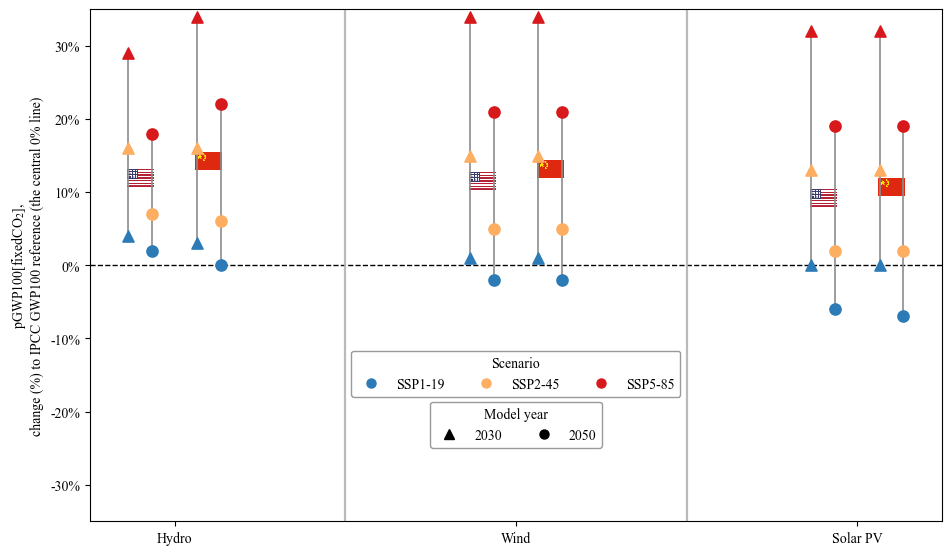

In [19]:
fig, ax = plot_fixedCO2_dumbbell_2030_2050_oneflag(
    df203050, 
    figsize=(11,8),
    scenario_order=["SSP1-VLLO", "SSP2-M", "SSP5-H"]
)
fig.savefig("fig_output/pGWP_fixedCO2_dumbbell_threeSSP_MY2030_2050.png", dpi=300, bbox_inches="tight")